%%benchmark --sweep --chart var=n start=1000 end=10000 step=1000 iterations=5 warmup=1
// Use a predefined test builder that accepts a Map factory (constructor reference)
java.util.Random rnd = new java.util.Random(12345);
int[] keys = new int[n];
for (int i = 0; i < n; i++) keys[i] = rnd.nextInt(n * 10);

import java.util.function.Supplier;
import java.util.Map;
// build a Supplier<Integer> that performs many lookups on a map created by mapFactory
Supplier<Integer> makeMapLookupTest(Supplier<Map<Integer,Integer>> mapFactory) {
  Map<Integer,Integer> map = mapFactory.get();
  for (int k : keys) map.put(k, k);
  java.util.Random localRnd = new java.util.Random(54321);
  return () -> {
    int acc = 0;
    for (int i = 0; i < 10000; i++) acc += (map.get(keys[localRnd.nextInt(keys.length)]) != null) ? 1 : 0;
    return acc;
  };
}

// HashMap: pass a constructor reference via a lambda (to set initial capacity)
runSupplierTest(makeMapLookupTest(() -> new java.util.HashMap<>(Math.max(16, n * 2))), 1);
---
// TreeMap: pass constructor reference directly
runSupplierTest(makeMapLookupTest(java.util.TreeMap::new), 1);

## Expressions

In [5]:
"Hello world !";

"Helloworld!";: Hello world !

In [6]:
3+4*2

3+4*2: 11

## Methods and Classes in cells

In [7]:
// Basic method example: define a helper class with a static method and call it
class Helper {
  static int add(int a, int b) { return a + b; }
}
System.out.println(Helper.add(2, 3));

5


In [8]:
// Simple class example: define a Person class and instantiate it
class Person {
  String name;
  Person(String name) { this.name = name; }
  String greet() { return "Hello, I am " + name; }
}
Person p = new Person("Alice");
System.out.println(p.greet());

Hello, I am Alice


## External compilation

In [9]:
%maven org.projectlombok:lombok:1.18.42

In [10]:
%%compile --help

## %%compile - Compile Java source code and add to classpath

**Usage:** `%%compile [--verbose] [--debug] [--nowarn] fully.qualified.ClassName`

**Arguments:**
- `className` : Fully qualified class name (e.g., com.example.MyClass)

**Options:**
- `--verbose, -v` : Enable verbose compilation output
- `--debug, -d` : Include debug information in compiled classes
- `--nowarn, -w` : Suppress compiler warnings
- `--help, -h` : Show this help message

**Examples:**
```
%%compile com.example.Calculator
public class Calculator {
    public int add(int a, int b) { return a + b; }
}
```

```
%%compile --verbose --debug com.example.MyClass
public class MyClass {
    public void hello() { System.out.println("Hello!"); }
}
```

**Note:** Package declaration will be added automatically if not present.



In [11]:
%%compile --class=com.example.demo.Hello --output=out
package com.example.demo;
public class Hello {
  public static String greet() { return "Hello from compiled class"; }
}

After the `%%compile` cell finishes, the compiled classes are placed in the specified `out` directory and are added to the kernel classpath automatically by the magics (as exercised by the tests).

In [12]:
com.example.demo.Hello.greet();

com.example.demo.Hello.greet();: Hello from compiled class

In [13]:
%%compile --class=com.example.demo.LombokPerson --output=out --processor-path=/var/home/bruno/.m2/repository/org/projectlombok/lombok/1.18.42/lombok-1.18.42.jar --classpath=/var/home/bruno/.m2/repository/org/projectlombok/lombok/1.18.42/lombok-1.18.42.jar
package com.example.demo;
import lombok.Data;
import lombok.AllArgsConstructor;
@Data
@AllArgsConstructor
public class LombokPerson {
  private String name;
  private int age;
}

In [14]:
// Instantiate and use the compiled Lombok class
com.example.demo.LombokPerson lp = new com.example.demo.LombokPerson("Bob", 30);
System.out.println(lp.getName() + " age=" + lp.getAge());
System.out.println(lp);

Bob age=30
LombokPerson(name=Bob, age=30)


## Shell

In [15]:
%%shell --help

## %%shell - Execute shell commands

**Usage:** `%%shell [--shell=SHELL] [--timeout=SECONDS]`

**Options:**
- `--shell=SHELL` : Shell to use (default: zsh, or $SHELL environment variable)
- `--timeout=SECONDS` : Maximum execution time in seconds (default: 180)
- `--help, -h` : Show this help message

**Examples:**
```
%%shell
ls -la
```

```
%%shell --shell=bash
echo "Using bash"
```

```
%%shell --timeout=60
long-running-command
```



In [16]:
%%shell
# Run a simple shell command. The shared executor streams stdout/stderr and preserves environment variables across cells when appropriate.
echo $SHELL
echo "Hello from shell"
export MYVAR=42
echo $MYVAR

bash
Hello from shell
42


In [17]:
%%shell --shell=zsh
echo $SHELL
echo "Hello from zsh shell"


bash
Hello from zsh shell


## Databases

In [18]:
%maven --help

%maven - Add individual Maven coordinates to the classpath

Usage: %maven <groupId>:<artifactId>[:<extension>[:<classifier>]]:<version> [<coord> ...]

Examples:
  %maven org.h2:h2:2.4.240
  %maven com.google.guava:guava:32.1.2-jre org.apache.commons:commons-lang3:3.12.0

Options:
  --help, -h    Show this help message

Notes:
  Coordinates must follow Maven coordinate format. Multiple coordinates may be provided.


In [19]:
%maven com.h2database:h2:2.4.240

In [20]:
System.setProperty("jdbc.url", "jdbc:h2:mem:test;DB_CLOSE_DELAY=-1");
System.setProperty("jdbc.user", "sa");
System.setProperty("jdbc.password", "");

In [21]:
%%sqlAsTable --help

In [22]:
%%sqlAsTable
-- Example using a jdbc connection defined by system properties jdbc.url, jdbc.user, jdbc.password
-- Creates multiple related tables and demonstrates inserts and joins

-- products catalog
CREATE TABLE IF NOT EXISTS products(id INT PRIMARY KEY, name VARCHAR(100), price DECIMAL(10,2));
MERGE INTO products VALUES
  (1, 'Widget', 9.99),
  (2, 'Gadget', 19.95),
  (3, 'Thingamajig', 4.50);

-- orders and order items
CREATE TABLE IF NOT EXISTS orders(id INT PRIMARY KEY, customer_id INT, order_date DATE);
-- use a composite primary key so MERGE INTO can match rows
CREATE TABLE IF NOT EXISTS order_items(order_id INT, product_id INT, qty INT, PRIMARY KEY(order_id, product_id));

MERGE INTO orders VALUES (1, 1, DATE '2025-12-01'), (2, 2, DATE '2025-12-02');
MERGE INTO order_items(order_id, product_id, qty) KEY(order_id, product_id) VALUES
  (1, 1, 2),
  (1, 3, 1),
  (2, 2, 4);

-- verify tables
SELECT * FROM products;
SELECT * FROM orders;
SELECT * FROM order_items;

-- example join: order totals per order
SELECT o.id AS order_id, o.order_date, d.name AS customer, SUM(p.price * oi.qty) AS total
FROM orders o
JOIN order_items oi ON oi.order_id = o.id
JOIN products p ON p.id = oi.product_id
GROUP BY o.id, o.order_date, d.name
;

Updated 3 rows

Updated 2 rows

Updated 3 rows

ID,NAME,PRICE
1,Widget,9.99
2,Gadget,19.95
3,Thingamajig,4.50


In [23]:
%%rdbmsSchema --help

## %%rdbmsSchema - Render DB schema as PlantUML

Usage: %%rdbmsSchema [--help] [<schema>] [SVG|PNG] [--show-source] [include=<regex>] [exclude=<regex>]

Provide table names in the cell body (one per line) to limit the diagram.


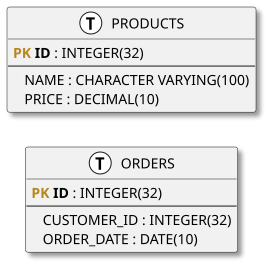

In [24]:
%%rdbmsSchema
-- Render the schema for a given JDBC connection as HTML/SVG (depends on implementation).
ORDERS
PRODUCTS

## Java source helper demos
These cells demonstrate the `%%javasrc*` magics for extracting classes, methods, constructors, fields, and Javadoc from source files. The demos use sample sources under `docs/sample_java` included in this repository.

In [25]:
%%javasrcClassByName --help

**Usage:** `%%javasrcClassByName <FullyQualifiedClassName>`

Extract entire class source by FQCN. Body may contain file path.

In [26]:
%%javasrcClassByName com.example.Greeter
../docs/sample_java/com/example/Greeter.java

```Java
public class Greeter {
    private final String name;

    public Greeter(String name) {
        this.name = name;
    }

    /**
     * Greets the person by name.
     * 
     * @return A greeting message.
     */
    public String greet() {
        return "Hello " + name;
    }
}
```

In [27]:
%%javasrcMethodByName --help

**Usage:** `%%javasrcMethodByName [options] <FullyQualifiedClassName|ClassName> [methodName|index]`

**Options:**
- `--src <dir>`: source root to resolve FQCN (e.g., `--src=sample_java`)
- `methodRegex=<regex>`: select methods whose name matches regex
- `selectIndex=<n>` or positional index: pick one when multiple matches
- `--raw` / `--fenced`: output format

**Examples:**
- `%%javasrcMethodByName methodRegex=summary --src=sample_java com.example.OrderExample`
- `%%javasrcMethodByName com.example.OrderExample myMethod`
- `%%javasrcMethodByName selectIndex=1 com.example.OrderExample myMethod`


In [28]:
%%javasrcMethodByName com.example.OrderExample summary
../docs/sample_java/com/example/OrderExample.java

```Java
/**
 * Returns a summary of the product.
 *
 * @param p The product to summarize.
 * @return A string summary of the product.
 */
public static String summary(Product p) {
    return p.id + ":" + p.name + ":" + p.price;
}
```

In [29]:
%%javasrcMethodByAnnotationName --help

**Usage:** `%%javasrcMethodByAnnotationName <FullyQualifiedClassName> <AnnotationName> [index]`

Extract methods annotated with a given annotation from source file (body should be path to file).

In [30]:
%%javasrcMethodByAnnotationName com.example.Product Deprecated
../docs/sample_java/com/example/Product.java

```Java
@Deprecated(since = 1)
public void oldMethod() {
    System.out.println("old ...");
}
```

In [31]:
%%javasrcConstructorByName --help

**Usage:** `%%javasrcConstructorByName <FullyQualifiedClassName>`

Show constructors for a class. Body may contain file path.

In [32]:
%%javasrcConstructorByName com.example.Product
../docs/sample_java/com/example/Product.java

```Java
0: Product(long, String)

public Product(long id, String name) {
    this(id, name, -1);
}

1: Product(long, String, double)

public Product(long id, String name, double price) {
    this.id = id;
    this.name = name;
    this.price = price;
}


```

In [33]:
%%javasrcFieldByName --help

**Usage:** `%%javasrcFieldByName <FullyQualifiedClassName> [filter] [--full=true]`

List or show fields for a class.

In [34]:
%%javasrcFieldByName com.example.Greeter
../docs/sample_java/com/example/Greeter.java

```Java
String name (modifiers: private  final )

private final String name;


```

In [35]:
%%javasrcJavadoc --help

**Usage:** `%%javasrcJavadoc <FullyQualifiedClassName> [memberName]`

Show javadoc for class or member.

In [36]:
%%javasrcJavadoc com.example.OrderExample
../docs/sample_java/com/example/OrderExample.java

OrderExample is a fake java class

- @see — Product

In [37]:
%%javasrcJavadoc com.example.OrderExample summary
../docs/sample_java/com/example/OrderExample.java

Returns a summary of the product.

- @param p — The product to summarize.
- @return — A string summary of the product.

## TimeIt demo
This cell demonstrates the `%%timeit` cell-magic (aliases `%%time`) to measure execution time. Use `iterations` and `warmup` to adjust sampling.

In [38]:
%%timeit --help

help: 
example: 

%%time epochs=3 loops=5
1 + 1


In [39]:
%%timeit iterations=5 warmup=1
// Simple workload: sum integers up to n and return the sum
int n = 100_000;
int s = 0;
for (int i = 0; i < n; i++) s += i;
s;

samples: [25110850, 23485074, 23968668, 17996648, 17317386]
min=17317386 median=23485074 avg=21575725,20 max=25110850 (nanoseconds)


## Benchmark: HashMap vs TreeMap
This cell runs the `%%benchmark` magic to compare `HashMap` and `TreeMap` performance. It performs a sweep over map sizes (`n`) and renders a chart. Adjust `start`/`end`/`step` to change the sweep range.

In [40]:
%%benchmark --help

## %%benchmark - Compare implementations performance

Usage: %%benchmark [--help] [--sweep var=<name> start=<n> end=<n> step=<n>] [--chart] [iterations=<n>] [warmup=<n>]\n
Provide one or more implementations separated by a line containing '---'.
Example:
%%benchmark iterations=5
code-for-impl-1
---
code-for-impl-2



In [41]:
// Helper: run a Supplier-driven test and return accumulated result
import java.util.function.Supplier;
// runSupplierTest calls the supplier 'iterations' times and accumulates its results
int runSupplierTest(Supplier<Integer> supplier, int iterations) {
  int acc = 0;
  for (int i = 0; i < iterations; i++) acc += supplier.get();
  return acc;
}

// Factory: build a Supplier that performs a mixed random read/write workload
// mapFactory: creates an empty Map<Integer,Integer>
// readRatio: fraction of operations that are reads (0.0-1.0)
// opsPerInvocation: number of random ops the supplier performs per get()
import java.util.Map;
import java.util.Random;
Supplier<Integer> makeMapRWTest(java.util.function.Supplier<Map<Integer,Integer>> mapFactory, double readRatio, int opsPerInvocation) {
  Map<Integer,Integer> map = mapFactory.get();
  Random initRnd = new Random(12345);
  // pre-populate map with a sparse keyspace
  for (int i = 0; i < n; i++) map.put(initRnd.nextInt(n * 10), i);
  Random localRnd = new Random(54321);
  return () -> {
    int localAcc = 0;
    for (int op = 0; op < opsPerInvocation; op++) {
      if (localRnd.nextDouble() < readRatio) {
        Integer v = map.get(localRnd.nextInt(n * 10));
        localAcc += (v != null) ? v : 0;
      } else {
        int key = localRnd.nextInt(n * 10);
        map.put(key, localRnd.nextInt());
      }
    }
    return localAcc;
  };
}

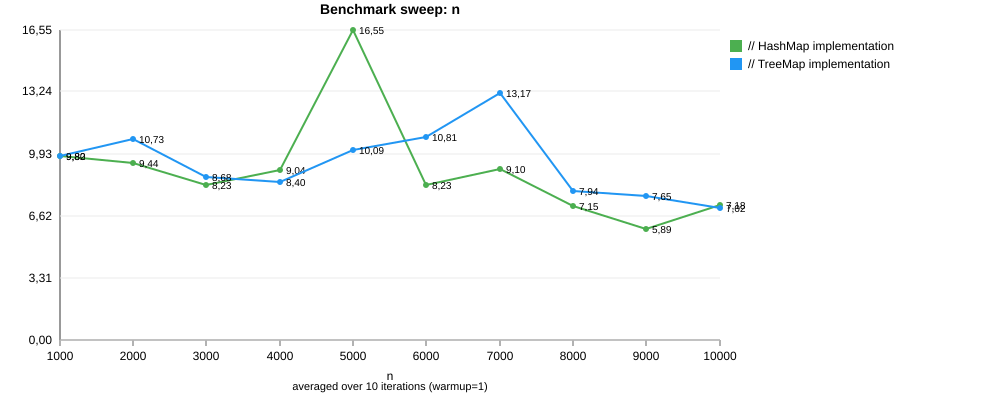

In [42]:
%%benchmark --sweep --chart var=n start=1000 end=10000 step=1000 iterations=10 warmup=1
// HashMap implementation
import java.util.HashMap;
java.util.function.Supplier<Integer> sanitySupplier = makeMapRWTest(() -> new java.util.HashMap<>(), 0.9, n);
---
// TreeMap implementation
import java.util.TreeMap;
java.util.function.Supplier<Integer> sanitySupplier = makeMapRWTest(() -> new java.util.TreeMap<>(), 0.9, n);

## Class diagrams

Examples showing the new `%classDiagram` and `%%classDiagram` magics.

In [8]:
%classDiagram --help

%classDiagram usage:
  %classDiagram <Class>
  %classDiagram --package=pkg [options]

Options:
  --svg | --png | --uml
  --include=regex --exclude=regex
  --interfaces-only --classes-only
  --ancestors --depth=N
  --max=N --non-public
  --out=file



In [7]:
%classDiagram com.example.demo.Hello

Classpath error: com.example.demo.Hello
No classes found.


In [1]:
%%compile --class=com.example.demo.C --output=out
package com.example.demo;
interface C {
    default int x() { return 42; }
}

In [2]:
%%compile --class=com.example.demo.A --output=out
package com.example.demo;
public class A implements C {
}

In [3]:
%%compile --class=com.example.demo.B --output=out
package com.example.demo;
public class B extends A {
}

In [2]:
%%classDiagram --package=com.example.demo --svg

No classes found.


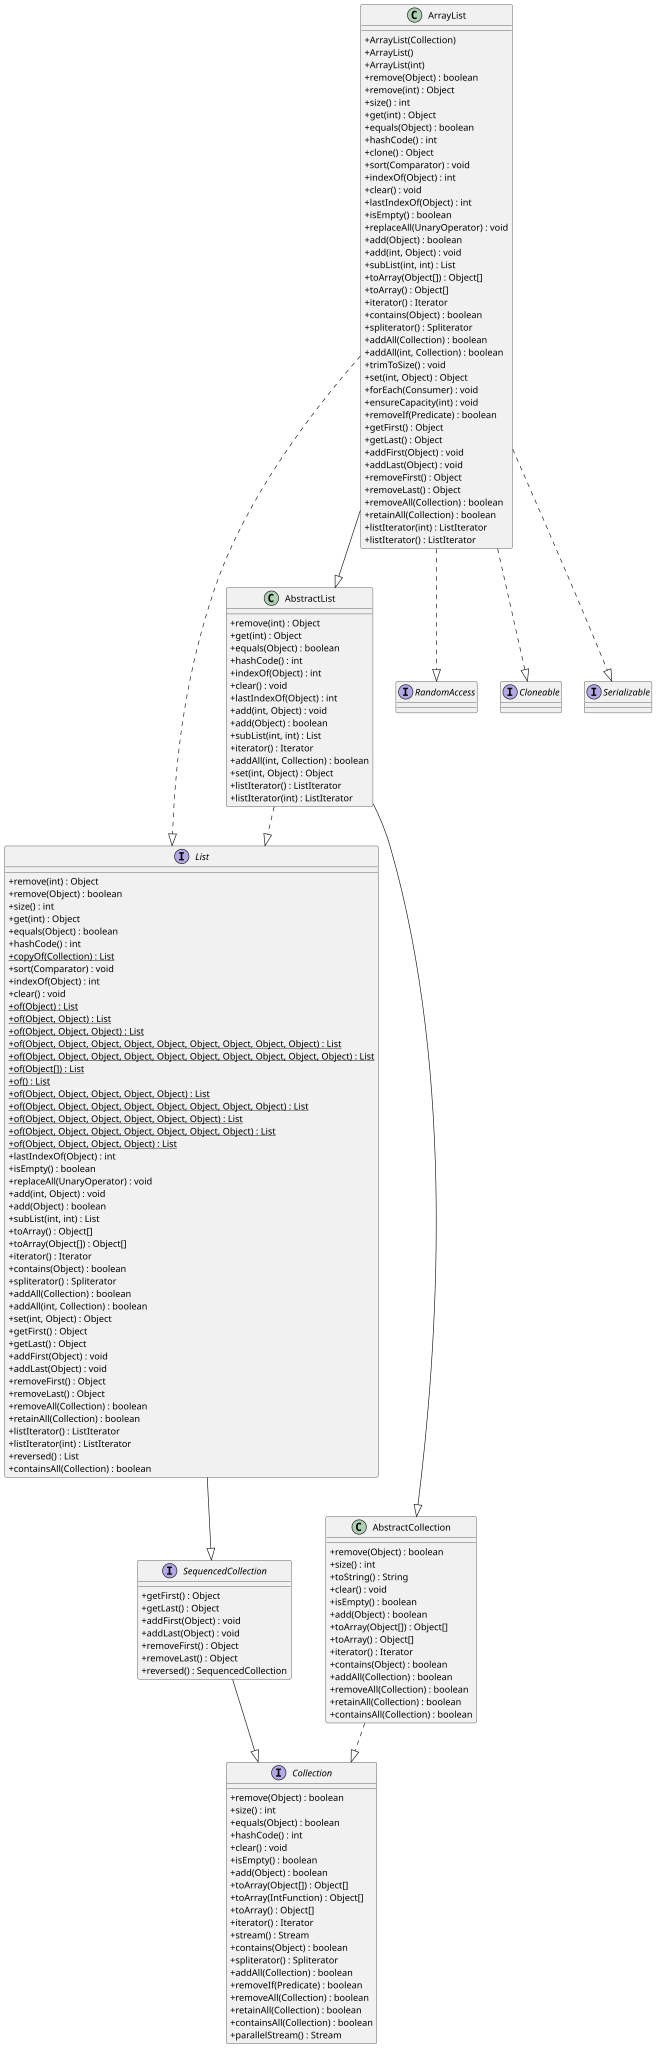

In [1]:
%%classDiagram java.util.ArrayList --svg --ancestors  --exclude-inherited